# Manifolds and Lie Groups Visualization

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

In [9]:
def set_axes_equal_3d(ax):
    """
    Set equal scaling for a 3D matplotlib axis.

    Matplotlib does not automatically use equal aspect ratio in 3D plots.
    This helper makes spheres look like spheres instead of ellipsoids.
    """
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    max_range = max(x_range, y_range, z_range)

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    radius = max_range / 2

    ax.set_xlim3d([x_middle - radius, x_middle + radius])
    ax.set_ylim3d([y_middle - radius, y_middle + radius])
    ax.set_zlim3d([z_middle - radius, z_middle + radius])

## Demo 1 — Embedding dimension vs intrinsic dimension

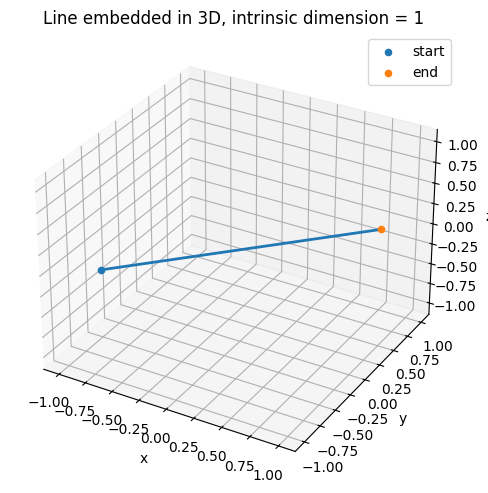

In [10]:
# A line in 3D can be described by one parameter t.
t = np.linspace(-1.0, 1.0, 200)

# Parametric line: p(t) = p0 + t * direction
p0 = np.array([0.0, 0.0, 0.0])
direction = np.array([1.0, 0.5, 0.3])

line_points = p0[:, None] + direction[:, None] * t

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    line_points[0],
    line_points[1],
    line_points[2],
    linewidth=2,
)

ax.scatter(line_points[0, 0], line_points[1, 0], line_points[2, 0], label="start")
ax.scatter(line_points[0, -1], line_points[1, -1], line_points[2, -1], label="end")

ax.set_title("Line embedded in 3D, intrinsic dimension = 1")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()

set_axes_equal_3d(ax)
plt.tight_layout()

plt.savefig(figures_dir / "line_embedded_in_3d.png", dpi=200)
plt.show()

Although this line is drawn in three-dimensional space, points on the line are determined by a single parameter $t$.
Therefore, its intrinsic dimension is 1, while its embedding dimension is 3.

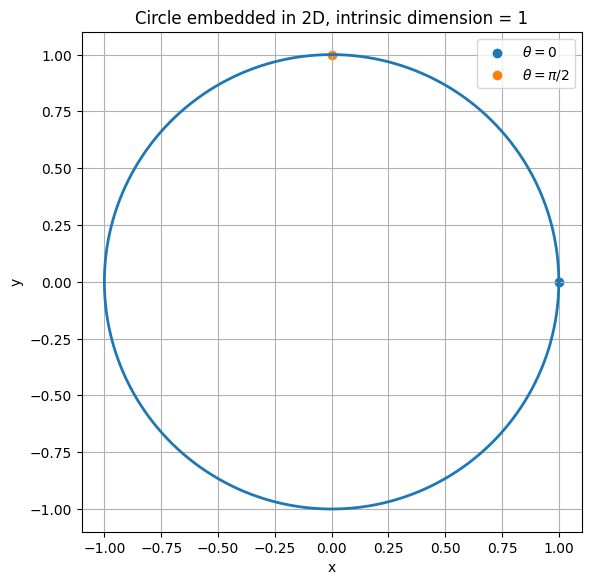

In [11]:
# A circle in 2D can be described by one parameter theta.
theta = np.linspace(0.0, 2.0 * np.pi, 400)

x = np.cos(theta)
y = np.sin(theta)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(x, y, linewidth=2)
ax.scatter([1.0], [0.0], label=r"$\theta = 0$")
ax.scatter([0.0], [1.0], label=r"$\theta = \pi/2$")

ax.set_title("Circle embedded in 2D, intrinsic dimension = 1")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig(figures_dir / "circle_embedded_in_2d.png", dpi=200)
plt.show()

The circle is embedded in two-dimensional space because it is drawn using \(x\) and \(y\) coordinates.
However, a point constrained to the circle can be described using only one independent parameter,
the angle \(\theta\). Therefore, the circle has intrinsic dimension 1.

## Demo 2 — Sphere surface as a 2D manifold embedded in 3D

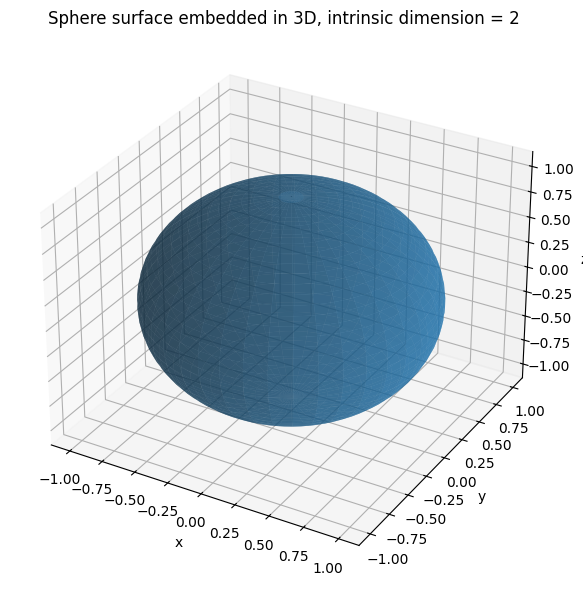

In [12]:
# A sphere surface in 3D can be described by two parameters:
# theta: azimuth angle
# phi: polar angle

theta = np.linspace(0.0, 2.0 * np.pi, 80)
phi = np.linspace(0.0, np.pi, 40)

theta_grid, phi_grid = np.meshgrid(theta, phi)

x = np.sin(phi_grid) * np.cos(theta_grid)
y = np.sin(phi_grid) * np.sin(theta_grid)
z = np.cos(phi_grid)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(x, y, z, alpha=0.6, linewidth=0)

ax.set_title("Sphere surface embedded in 3D, intrinsic dimension = 2")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

set_axes_equal_3d(ax)
plt.tight_layout()

plt.savefig(figures_dir / "sphere_surface_embedded_in_3d.png", dpi=200)
plt.show()

The sphere surface is embedded in three-dimensional space because each point has coordinates $(x, y, z)$.
However, if motion is constrained to the surface, only two independent coordinates are needed locally.
For example, a point on the unit sphere can be parameterized by two angles: $\theta$ and $\phi$.
Therefore, the sphere surface has intrinsic dimension 2.

In [13]:
import pandas as pd

summary = pd.DataFrame(
    {
        "Object": [
            "Line in 3D",
            "Circle in 2D",
            "Sphere surface in 3D",
        ],
        "Embedding dimension": [
            3,
            2,
            3,
        ],
        "Intrinsic dimension": [
            1,
            1,
            2,
        ],
        "Independent parameters": [
            "t",
            "theta",
            "theta, phi",
        ],
    }
)

summary

,Object,Embedding dimension,Intrinsic dimension,Independent parameters
0,Line in 3D,3,1,t
1,Circle in 2D,2,1,theta
2,Sphere surface in 3D,3,2,"theta, phi"


The intrinsic dimension tells us how many independent coordinates are needed
to describe motion constrained to the object.
This is different from the embedding dimension,
which tells us the dimension of the surrounding space in which the object is represented.

This distinction is important in robotics because rotation matrices in $SO(3)$
are represented as $3 \times 3$ matrices with nine entries,
but the space of valid 3D rotations has only three intrinsic degrees of freedom.

## Demo 3 — Rotation matrices are constrained objects

A 3D rotation matrix is not an arbitrary $3 \times 3$ matrix.
A valid rotation matrix $R \in SO(3)$ must satisfy:

$$
R^T R = I
$$

and

$$
\det(R) = 1
$$

These conditions mean that the columns of $R$ form an orthonormal
right-handed coordinate frame.

In this demo, two valid rotation matrices are created.
Their product is still a valid rotation matrix,
because rotation composition is closed under matrix multiplication.
However, their sum is generally not a valid rotation matrix.

In [14]:
import numpy as np

def rot_x(theta: float) -> np.ndarray:
    """
    Return a 3D rotation matrix for rotation about the x-axis.
    """
    c = np.cos(theta)
    s = np.sin(theta)

    return np.array([
        [1.0, 0.0, 0.0],
        [0.0, c, -s],
        [0.0, s, c],
    ])


def rot_y(theta: float) -> np.ndarray:
    """
    Return a 3D rotation matrix for rotation about the y-axis.
    """
    c = np.cos(theta)
    s = np.sin(theta)

    return np.array([
        [c, 0.0, s],
        [0.0, 1.0, 0.0],
        [-s, 0.0, c],
    ])


def rot_z(theta: float) -> np.ndarray:
    """
    Return a 3D rotation matrix for rotation about the z-axis.
    """
    c = np.cos(theta)
    s = np.sin(theta)

    return np.array([
        [c, -s, 0.0],
        [s, c, 0.0],
        [0.0, 0.0, 1.0],
    ])


def is_rotation_matrix(R: np.ndarray, tolerance: float = 1e-9) -> bool:
    """
    Check whether a matrix is a valid 3D rotation matrix.

    A valid rotation matrix satisfies:
        R.T @ R = I
        det(R) = 1
    """
    R = np.asarray(R, dtype=float)

    if R.shape != (3, 3):
        return False

    orthogonality_error = np.linalg.norm(R.T @ R - np.eye(3))
    determinant = np.linalg.det(R)

    return (
        orthogonality_error < tolerance
        and np.isclose(determinant, 1.0, atol=tolerance)
    )


def rotation_matrix_report(R: np.ndarray, name: str) -> None:
    """
    Print diagnostic information for a candidate rotation matrix.
    """
    orthogonality_error = np.linalg.norm(R.T @ R - np.eye(3))
    determinant = np.linalg.det(R)
    valid = is_rotation_matrix(R)

    print(f"{name}")
    print("-" * len(name))
    print(f"Orthogonality error ||R.T @ R - I||: {orthogonality_error:.6e}")
    print(f"Determinant det(R): {determinant:.6f}")
    print(f"Valid rotation matrix: {valid}")
    print()

In [18]:
R1 = rot_z(np.deg2rad(30))
R2 = rot_y(np.deg2rad(45))

R_product = R1 @ R2
R_sum = R1 + R2

rotation_matrix_report(R1, "R1: rotation about z-axis")
rotation_matrix_report(R2, "R2: rotation about y-axis")
rotation_matrix_report(R_product, "R_product = R1 @ R2")
rotation_matrix_report(R_sum, "R_sum = R1 + R2")

R1: rotation about z-axis
-------------------------
Orthogonality error ||R.T @ R - I||: 1.051763e-17
Determinant det(R): 1.000000
Valid rotation matrix: True

R2: rotation about y-axis
-------------------------
Orthogonality error ||R.T @ R - I||: 1.434937e-17
Determinant det(R): 1.000000
Valid rotation matrix: True

R_product = R1 @ R2
-------------------
Orthogonality error ||R.T @ R - I||: 1.379722e-16
Determinant det(R): 1.000000
Valid rotation matrix: True

R_sum = R1 + R2
---------------
Orthogonality error ||R.T @ R - I||: 4.307303e+00
Determinant det(R): 6.371009
Valid rotation matrix: False



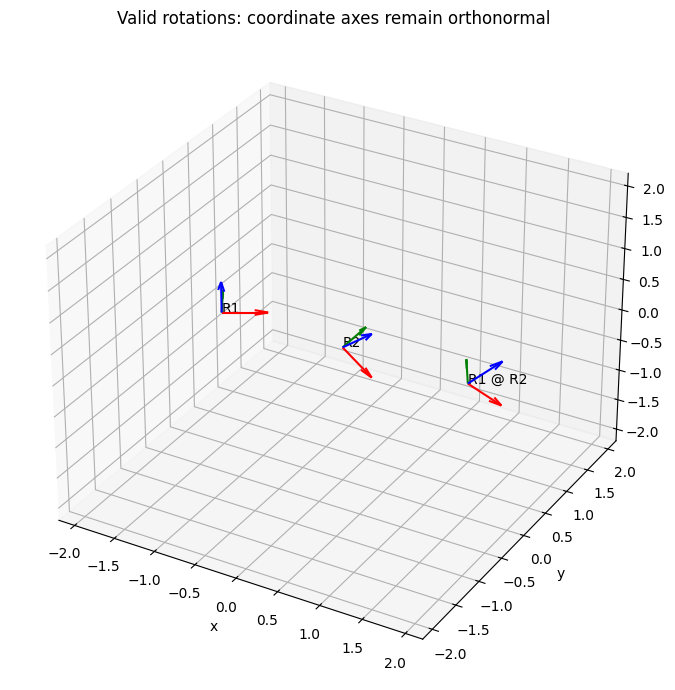

In [19]:
def plot_rotated_frame_3d(ax, R: np.ndarray, origin: np.ndarray, name: str, length: float = 0.5):
    """
    Plot the coordinate frame represented by the columns of a rotation matrix.

    The first, second, and third columns of R are the x-, y-, and z-axes
    of the rotated frame expressed in the reference frame.
    """
    x_axis = R[:, 0]
    y_axis = R[:, 1]
    z_axis = R[:, 2]

    ax.quiver(*origin, *(length * x_axis), color="r")
    ax.quiver(*origin, *(length * y_axis), color="g")
    ax.quiver(*origin, *(length * z_axis), color="b")

    ax.text(*origin, name)


fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

plot_rotated_frame_3d(ax, R1, np.array([-1.5, 0.0, 0.0]), "R1")
plot_rotated_frame_3d(ax, R2, np.array([0.0, 0.0, 0.0]), "R2")
plot_rotated_frame_3d(ax, R_product, np.array([1.5, 0.0, 0.0]), "R1 @ R2")

ax.set_title("Valid rotations: coordinate axes remain orthonormal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-1.2, 1.2)
ax.set_zlim(-1.2, 1.2)

set_axes_equal_3d(ax)

plt.tight_layout()
plt.savefig(figures_dir / "valid_rotation_composition.png", dpi=200)
plt.show()

The product $R_1 R_2$ is still a valid rotation matrix.
This demonstrates the closure property of the rotation group $SO(3)$:
composing two rotations produces another rotation.

The sum $R_1 + R_2$, however, is not generally a valid rotation matrix.
Its columns are no longer guaranteed to be unit length and mutually orthogonal,
and its determinant is generally not equal to 1.

This shows why rotations should not be treated as ordinary vectors in Euclidean space.
Even though a rotation matrix is stored as nine numbers, those numbers are constrained.
The valid rotations form a curved space, not a flat vector space.

## Demo 4 — Local updates on SO(3) using the exponential map

The space of 3D rotation, $SO(3)$, is not a vector space.
Therefore, a rotation matrix should not generally be updated by simple matrix addition.

Instead, a small rotation can be represented locally by a 3D rotation vector:

$$
\omega =
\begin{bmatrix}
\omega_x \\
\omega_y \\
\omega_z
\end{bmatrix}
$$

This vector is an axis-angle representation:

- the direction of $\omega$ defines the rotation axis,
- the norm $\theta = \|\omega\|$ defines the rotation angle in radians.

This vector ($\omega$) lives in a local tangent space.
To apply the update while staying on $SO(3)$, the vector is converted into a skew-symmetric
matrix and mapped back to a valid rotation matrix using the exponential map:

$$
R_{\text{new}} = R \exp([\omega]_\times)
$$

where $[\omega]_\times$ is the skew-symmetric matrix representation of $\omega$.

---

### Why use a skew-symmetric matrix?

The exponential map for rotations is defined using an element of the Lie algebra $\mathfrak{so}(3)$.
The Lie algebra $\mathfrak{so}(3)$ consists of $3 \times 3$ skew-symmetric matrices.

A 3D vector $\omega$ can be converted into a skew-symmetric matrix:

$$
[\omega]_\times =
\begin{bmatrix}
0 & -\omega_z & \omega_y \\
\omega_z & 0 & -\omega_x \\
-\omega_y & \omega_x & 0
\end{bmatrix}
$$

This matrix has an important property:

$$
[\omega]_\times v = \omega \times v
$$

for any vector $v \in \mathbb{R}^3$.

So the skew-symmetric matrix is the matrix representation of the cross-product operation.
In robotics, this is useful because rotational velocity and infinitesimal rotations are naturally related to cross products.

---

### Why use Rodrigues' formula?

The matrix exponential

$$
\exp([\omega]_\times)
$$

maps the local rotation vector $\omega$ back to a valid rotation matrix in $SO(3)$.

Computing a general matrix exponential is possible,
but for 3D rotations there is a closed-form expression called **Rodrigues' formula**.

Let

$$
\theta = \|\omega\|
$$

Then:

$$
\exp([\omega]_\times)
=
I
+
\frac{\sin\theta}{\theta}[\omega]_\times
+
\frac{1-\cos\theta}{\theta^2}[\omega]_\times^2
$$

This formula is useful because it directly converts an axis-angle rotation
vector into a rotation matrix while preserving the constraints of $SO(3)$:

$$
R^T R = I
$$

and

$$
\det(R) = 1
$$

In other words, Rodrigues' formula gives a computationally efficient way to move from the local tangent-space
representation back onto the rotation manifold.

In [ ]:
def skew(vector: np.ndarray) -> np.ndarray:
    """
    Return the skew-symmetric matrix of a 3D vector.

    For a vector w = [wx, wy, wz], the skew-symmetric matrix [w]_x is:

        [  0  -wz   wy ]
        [ wz    0  -wx ]
        [-wy   wx    0 ]

    This matrix satisfies:

        [w]_x @ v = w x v

    where x denotes the vector cross product.
    """
    vector = np.asarray(vector, dtype=float).reshape(3)
    wx, wy, wz = vector

    return np.array([
        [0.0, -wz, wy],
        [wz, 0.0, -wx],
        [-wy, wx, 0.0],
    ])

In [ ]:
def so3_exp(omega: np.ndarray) -> np.ndarray:
    """
    Map a 3D rotation vector to a valid 3D rotation matrix using the exponential map.

    The input vector omega represents an axis-angle rotation:
    - its direction is the rotation axis,
    - its norm is the rotation angle in radians.

    Rodrigues' formula is used to compute the matrix exponential.
    """
    omega = np.asarray(omega, dtype=float).reshape(3)
    theta = np.linalg.norm(omega)

    omega_hat = skew(omega)

    if theta < 1e-12:
        # First-order approximation for very small rotations.
        return np.eye(3) + omega_hat

    return (
        np.eye(3)
        + (np.sin(theta) / theta) * omega_hat
        + ((1.0 - np.cos(theta)) / theta**2) * (omega_hat @ omega_hat)
    )

In [ ]:
R_initial = rot_z(np.deg2rad(30))

# Small local rotation vector.
# Direction: arbitrary 3D axis
# Magnitude: rotation angle in radians
omega = np.array([0.15, -0.10, 0.20])

R_update = so3_exp(omega)
R_new = R_initial @ R_update

rotation_matrix_report(R_initial, "R_initial")
rotation_matrix_report(R_update, "R_update = exp([omega]_x)")
rotation_matrix_report(R_new, "R_new = R_initial @ R_update")

In [ ]:
R_bad = R_initial + skew(omega)

rotation_matrix_report(R_bad, "R_bad = R_initial + [omega]_x")

In [ ]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

plot_rotated_frame_3d(ax, R_initial, np.array([-1.5, 0.0, 0.0]), "R_initial")
plot_rotated_frame_3d(ax, R_new, np.array([0.0, 0.0, 0.0]), "R_new")
plot_rotated_frame_3d(ax, R_bad, np.array([1.5, 0.0, 0.0]), "R_bad")

ax.set_title("Rotation update: exponential map vs. additive update")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-1.2, 1.2)
ax.set_zlim(-1.2, 1.2)

set_axes_equal_3d(ax)

plt.tight_layout()
plt.savefig(figures_dir / "so3_exponential_map_update.png", dpi=200)
plt.show()

In [ ]:
results_update = pd.DataFrame(
    {
        "Matrix": [
            "R_initial",
            "R_update = exp([omega]_x)",
            "R_new = R_initial @ R_update",
            "R_bad = R_initial + [omega]_x",
        ],
        "Orthogonality error": [
            np.linalg.norm(R_initial.T @ R_initial - np.eye(3)),
            np.linalg.norm(R_update.T @ R_update - np.eye(3)),
            np.linalg.norm(R_new.T @ R_new - np.eye(3)),
            np.linalg.norm(R_bad.T @ R_bad - np.eye(3)),
        ],
        "det(R)": [
            np.linalg.det(R_initial),
            np.linalg.det(R_update),
            np.linalg.det(R_new),
            np.linalg.det(R_bad),
        ],
        "Valid rotation": [
            is_rotation_matrix(R_initial),
            is_rotation_matrix(R_update),
            is_rotation_matrix(R_new),
            is_rotation_matrix(R_bad),
        ],
    }
)

results_update

The exponential-map update keeps the result on $SO(3)$.
The local vector $\omega$ is first interpreted as a small axis-angle rotation
and converted into a valid rotation matrix $R_{\text{update}}$.
Composing this update with the initial rotation gives another valid rotation matrix.

The additive update does not preserve the rotation constraints.
Although $R_{\text{initial}} + [\omega]_\times$ may look like a small perturbation,
the resulting matrix is generally not orthogonal and its determinant is not equal to 1.

This demonstrates why robotics algorithms usually update orientations through group operations,
such as multiplication with an exponential-map update, rather than ordinary addition.